# UIT-VSFC — Exploratory Data Analysis

**Gate G0.** Every number in this notebook is computed from the downloaded data, and every
analysis function lives in `vifeedback` and is covered by tests — the notebook narrates, it does
not implement (docs/ROADMAP.md § 4). Re-running it end to end reproduces
[`docs/DATA_CARD.md`](../docs/DATA_CARD.md).

**What this notebook is for.** Not description for its own sake. Each section ends in a
*decision* — `max_length`, which preprocessing conditions are worth running, which metric leads
the results table, what the error analysis should look for. Where an analysis changed the plan,
the ADR is named.

---

## 0. Setup


In [1]:
import json
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from vifeedback.data import integrity as I
from vifeedback.data import vocabulary as V
from vifeedback.data.loader import MANIFEST, load_all
from vifeedback.data.profile import surface_properties, teencode_presence

warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 9, 'axes.grid': True, 'grid.alpha': 0.3})

dfs = load_all()
train, dev, test = dfs['train'], dfs['validation'], dfs['test']
full = pd.concat(dfs.values(), ignore_index=True)
print(f'train {len(train):,} | dev {len(dev):,} | test {len(test):,} | total {len(full):,}')


train 11,426 | dev 1,583 | test 3,166 | total 16,175


---

## 1. Provenance and integrity

The corpus ships as a legacy loading script that pulls nine text files from Google Drive; we read
the Hub's auto-converted parquet branch instead and pin every file by SHA256. If the upstream
ever changes, the assertions below fail rather than silently producing numbers against different
data.


In [2]:
print(json.dumps(json.loads(MANIFEST.read_text(encoding='utf-8')), indent=2)[:700])


{
  "dataset": "uitnlp/vietnamese_students_feedback",
  "source": "uitnlp/vietnamese_students_feedback@refs/convert/parquet",
  "splits": {
    "train": {
      "file": "train.parquet",
      "rows": 11426,
      "sha256": "568f1221ae4846a617585f3e2eb474ae51df5dc9d1dd6a6223e693d5c011df25"
    },
    "validation": {
      "file": "validation.parquet",
      "rows": 1583,
      "sha256": "8d87f472229762cb50a8df20cdba38ffff25a5726c788a4309eed95e573ec7da"
    },
    "test": {
      "file": "test.parquet",
      "rows": 3166,
      "sha256": "dada9e9e4f8dd3ed9796704337e12ef5a918268ef85c8f7f9cd6edf2a392c915"
    }
  }
}


In [3]:
for name, check in (
    ('split sizes', I.check_split_sizes(dfs)),
    ('labels', I.check_labels(dfs)),
    ('text quality', I.check_text_quality(dfs)),
):
    print(f"{name:<14s} {'PASS' if check['passed'] else 'FAIL'}")

print()
print(pd.DataFrame(I.check_split_sizes(dfs)['actual'], index=['rows']).T)


split sizes    PASS
labels         PASS
text quality   PASS

             rows
train       11426
validation   1583
test         3166


Sample rows. Note immediately that the text is **already lowercased and punctuation-separated** —
this is not raw user input, and that fact drives two later decisions.


In [4]:
train.head(8)


,sentence,sentiment,topic
0,slide giáo trình đầy đủ .,2,1
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0
2,đi học đầy đủ full điểm chuyên cần .,0,1
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0
5,"giảng viên đảm bảo thời gian lên lớp , tích cự...",2,0
6,"em sẽ nợ môn này , nhưng em sẽ học lại ở các h...",1,3
7,"thời lượng học quá dài , không đảm bảo tiếp th...",0,1


---

## 2. Class distribution — the fact the whole project is built on


In [5]:
for task in ('sentiment', 'topic'):
    print(f'--- {task} ---')
    display(I.class_distribution(dfs, task))


--- sentiment ---


,split,n,negative,negative_pct,neutral,neutral_pct,positive,positive_pct
0,train,11426,5325,46.60,458,4.01,5643,49.39
1,validation,1583,705,44.54,73,4.61,805,50.85
2,test,3166,1409,44.50,167,5.27,1590,50.22
3,ALL,16175,7439,45.99,698,4.32,8038,49.69


--- topic ---


,split,n,lecturer,lecturer_pct,training_program,training_program_pct,facility,facility_pct,others,others_pct
0,train,11426,8166,71.47,2201,19.26,497,4.35,562,4.92
1,validation,1583,1151,72.71,267,16.87,70,4.42,95,6.00
2,test,3166,2290,72.33,572,18.07,145,4.58,159,5.02
3,ALL,16175,11607,71.76,3040,18.79,712,4.40,816,5.04


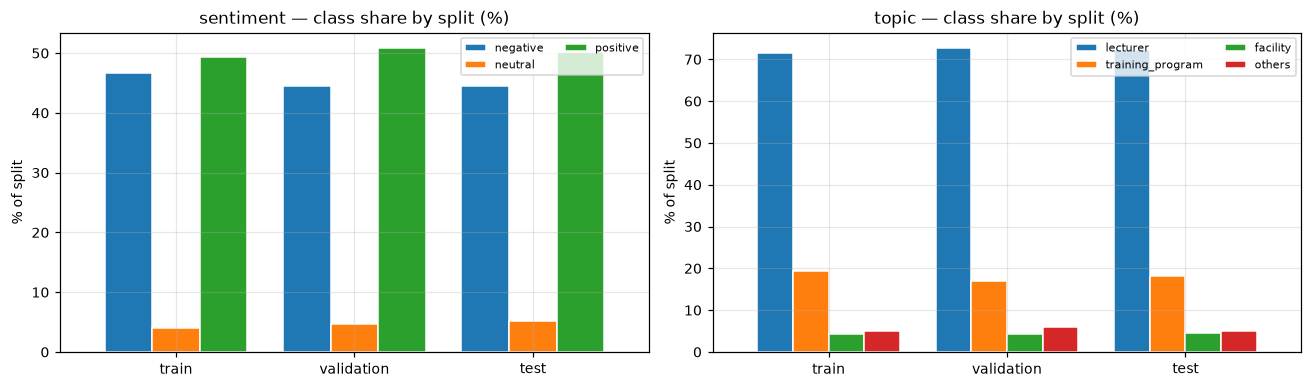

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, task in zip(axes, ('sentiment', 'topic')):
    d = I.class_distribution(dfs, task).set_index('split')
    names = [c for c in d.columns if not c.endswith('_pct') and c != 'n']
    d.loc[['train', 'validation', 'test'], [f'{n}_pct' for n in names]].rename(
        columns=lambda c: c[:-4]
    ).plot(kind='bar', ax=ax, rot=0, width=0.8, edgecolor='white')
    ax.set_title(f'{task} — class share by split (%)')
    ax.set_ylabel('% of split'); ax.set_xlabel('')
    ax.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()


### What this costs, stated exactly

A classifier that never predicts `neutral` but is otherwise **perfect** on the real test split:


In [7]:
from vifeedback.evaluation import metrics as M

y = test['sentiment'].to_numpy()
blind = y.copy()
neu = np.where(y == 1)[0]
blind[neu[: len(neu) // 2]] = 0
blind[neu[len(neu) // 2 :]] = 2
m = M.evaluate(y, blind, 'sentiment')

pd.Series({
    'accuracy': m['accuracy'],
    'weighted F1': m['weighted_f1'],
    'macro F1': m['macro_f1'],
    'neutral F1': m['per_class']['neutral']['f1'],
}).round(4).to_frame('never predicts neutral')


,never predicts neutral
accuracy,0.9473
weighted F1,0.9216
macro F1,0.6486
neutral F1,0.0000


**0.947 accuracy, 0.922 weighted F1, 0.649 macro-F1.** Three metrics, one model, and only one of
them notices that an entire class is missing. Published UIT-VSFC results in the 92–94% range are
weighted-F1 or accuracy figures — within reach of a model that has learned nothing about neutral.

**Decision (ADR-001): macro-F1 is the headline metric**, with weighted F1 always printed beside it.


---

## 3. Are the two tasks independent?

If they are, a multi-task model has nothing to share and the idea can be dropped before spending
GPU hours on it.


In [8]:
joint = I.joint_distribution(dfs)
within_topic = (100 * joint / joint.sum(axis=0)).round(1)
print('counts:'); display(joint)
print('sentiment share WITHIN each topic (%):'); display(within_topic)
print(f"Cramér's V = {I.cramers_v(joint):.4f}")


counts:


topic,lecturer,training_program,facility,others
sentiment,,,,
negative,4105,2328,681,325
neutral,292,162,13,231
positive,7210,550,18,260


sentiment share WITHIN each topic (%):


topic,lecturer,training_program,facility,others
sentiment,,,,
negative,35.4,76.6,95.6,39.8
neutral,2.5,5.3,1.8,28.3
positive,62.1,18.1,2.5,31.9


Cramér's V = 0.3437


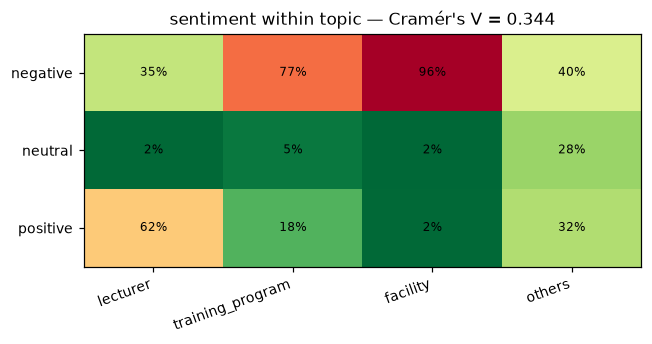

In [9]:
fig, ax = plt.subplots(figsize=(6, 3.2))
im = ax.imshow(within_topic.values, cmap='RdYlGn_r', aspect='auto')
ax.set_xticks(range(joint.shape[1]), joint.columns, rotation=20, ha='right')
ax.set_yticks(range(joint.shape[0]), joint.index)
for r in range(joint.shape[0]):
    for c in range(joint.shape[1]):
        ax.text(c, r, f'{within_topic.values[r, c]:.0f}%', ha='center', va='center', fontsize=8)
ax.set_title("sentiment within topic — Cramér's V = %.3f" % I.cramers_v(joint))
ax.grid(False)
plt.tight_layout(); plt.show()


**Not independent.** Feedback about `facility` is **95.6% negative**; about `lecturer`, **62.1%
positive**. And `neutral` is **28.3% of `others`** against **2.5% of `lecturer`** — an 11× ratio.

**Decision:** the multi-task experiment (shared encoder, two heads) is justified *before* running
it, and topic is a strong auxiliary signal specifically for the hard class.


---

## 4. Length — and the `max_length` decision

Vietnamese is written in whitespace-separated *syllables*, so a whitespace token count is a
syllable count, not a word count. What matters for the model is the **subword** count.


In [10]:
print(json.dumps(I.length_stats(dfs), indent=2))


{
  "train": {
    "chars": {
      "p50": 47,
      "p90": 110,
      "p95": 141,
      "p99": 218,
      "p100": 660,
      "mean": 59.08
    },
    "syllables": {
      "p50": 11,
      "p90": 26,
      "p95": 33,
      "p99": 52,
      "p100": 159,
      "mean": 14.31
    }
  },
  "validation": {
    "chars": {
      "p50": 45,
      "p90": 105,
      "p95": 132,
      "p99": 196,
      "p100": 718,
      "mean": 56.36
    },
    "syllables": {
      "p50": 11,
      "p90": 25,
      "p95": 31,
      "p99": 46,
      "p100": 161,
      "mean": 13.67
    }
  },
  "test": {
    "chars": {
      "p50": 46,
      "p90": 111,
      "p95": 147,
      "p99": 221,
      "p100": 411,
      "mean": 58.84
    },
    "syllables": {
      "p50": 11,
      "p90": 26,
      "p95": 34,
      "p99": 52,
      "p100": 98,
      "mean": 14.22
    }
  }
}


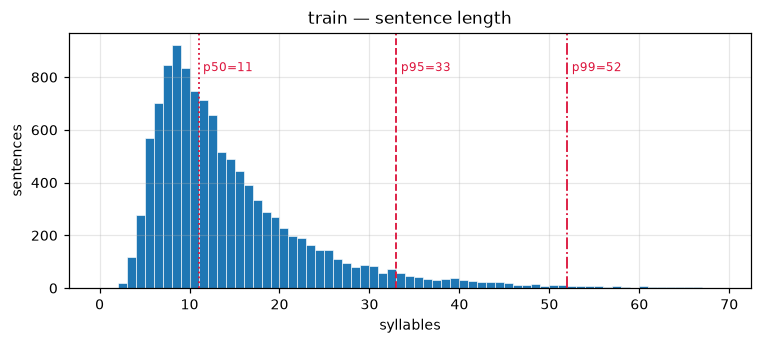

In [11]:
from vifeedback.preprocess import syllable_count

syl = train['sentence'].map(syllable_count)
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(syl, bins=range(0, 70), edgecolor='white', linewidth=0.4)
for q, st in ((50, ':'), (95, '--'), (99, '-.')):
    v = np.percentile(syl, q)
    ax.axvline(v, ls=st, lw=1.2, color='crimson')
    ax.text(v + 0.5, ax.get_ylim()[1] * 0.85, f'p{q}={v:.0f}', fontsize=8, color='crimson')
ax.set_xlabel('syllables'); ax.set_ylabel('sentences')
ax.set_title('train — sentence length')
plt.tight_layout(); plt.show()


In [12]:
report = json.loads((__import__('pathlib').Path('../results/data_report.json')).read_text(encoding='utf-8'))
tl = report['token_lengths']
print(f"tokenizer: {tl['model']}  vocab={tl['vocab_size']:,}")
display(pd.DataFrame({s: tl['splits'][s]['percentiles'] for s in tl['splits']}).T)
print('truncation cost by max_length (train):')
display(pd.DataFrame(tl['splits']['train']['truncation']).T)
print(json.dumps(report['max_length_decision'], indent=2))


tokenizer: vinai/phobert-base  vocab=64,000


,p50,p90,p95,p99,p99.9,p100
train,14,29,36,55,87,163
validation,13,27,35,52,90,164
test,13,29,37,55,83,102


truncation cost by max_length (train):


,n,share
32,811.0,0.07098
64,62.0,0.00543
96,8.0,0.00070
128,1.0,0.00009
256,0.0,0.00000


{
  "max_length": 96,
  "tolerance": 0.001,
  "worst_split_truncation_share": 0.0007,
  "vs_model_default_256": 2.67,
  "rationale": "Smallest candidate truncating <= 0.1% of sentences in every split; 2.7x shorter than the model default of 256."
}


**Decision: `max_length = 96`.** It truncates 8 train and 2 test sentences (< 0.1%), and is
**2.7× shorter than PhoBERT's 256 default**. Measured later in Phase 6, that one choice plus
dynamic padding cut FP32 CPU p95 from 177.5 ms to 50.8 ms — **3.49×, before any quantization**.

An EDA decision that turned out to be the single largest latency win in the project.


---

## 5. Duplicates and leakage

The check that can invalidate every later number. Published regardless of what it says.


In [13]:
leak = I.leakage_summary(dfs)
print(json.dumps(leak['headline'], indent=2))
print()
print('cross-split overlap, normalized (lowercase + diacritics stripped + punctuation removed):')
display(pd.DataFrame(leak['normalized']['cross']).T)


{
  "test_rows_seen_in_train_exact": 0,
  "test_rows_seen_in_train_normalized": 55,
  "share_of_test_exact": 0.0,
  "share_of_test_normalized": 0.0174
}

cross-split overlap, normalized (lowercase + diacritics stripped + punctuation removed):


,shared_keys,rows_in_train,rows_in_validation,share_of_validation,rows_in_test,share_of_test
train|validation,35.0,41.0,35.0,0.0221,NaN,NaN
train|test,52.0,60.0,NaN,NaN,55.0,0.0174
validation|test,11.0,NaN,11.0,NaN,13.0,0.0041


**0 exact, 55 normalized test rows (1.74%) — immaterial, and disclosed.**

The more interesting output of this check is what the matched pairs reveal about the *labels*.


In [14]:
from vifeedback.preprocess import dedup_key
from vifeedback.constants import LABELS

tr, te = train.copy(), test.copy()
tr['k'] = tr['sentence'].map(dedup_key)
te['k'] = te['sentence'].map(dedup_key)
pairs = te.merge(tr, on='k', suffixes=('_te', '_tr'))

print(f'matched pairs: {len(pairs)}')
print(f"sentiment agrees: {(pairs.sentiment_te == pairs.sentiment_tr).sum()}/{len(pairs)}")
print(f"topic agrees    : {(pairs.topic_te == pairs.topic_tr).sum()}/{len(pairs)}")

dis = pairs[(pairs.sentiment_te != pairs.sentiment_tr) | (pairs.topic_te != pairs.topic_tr)]
dis[['sentence_te', 'sentiment_te', 'topic_te', 'sentence_tr', 'sentiment_tr', 'topic_tr']].assign(
    sentiment_te=lambda d: d.sentiment_te.map(LABELS['sentiment']),
    sentiment_tr=lambda d: d.sentiment_tr.map(LABELS['sentiment']),
    topic_te=lambda d: d.topic_te.map(LABELS['topic']),
    topic_tr=lambda d: d.topic_tr.map(LABELS['topic']),
)


matched pairs: 63
sentiment agrees: 60/63
topic agrees    : 61/63


,sentence_te,sentiment_te,topic_te,sentence_tr,sentiment_tr,topic_tr
18,em xin cám ơn !,positive,others,em xin cám ơn .,neutral,others
19,em xin cám ơn !,positive,others,em xin cảm ơn !,neutral,others
22,truyền đạt tốt .,positive,lecturer,truyền dạt tốt .,positive,others
60,đến lớp đúng giờ !,positive,training_program,đến lớp dúng giờ !,neutral,training_program
61,đến lớp đúng giờ !,positive,training_program,đến lớp đúng giờ .,positive,lecturer


**~4.8% disagreement on textually identical pairs.** Politeness formulae (`em xin cám ơn`) are
annotated inconsistently between `neutral` and `positive`, and that phrase family is a visible
part of the neutral class.

This is a **measured bound on the achievable ceiling**, and it belongs in the model card.


---

## 6. Orthographic profile — two planning assumptions overturned

The project scope named *teencode* and *missing diacritics* as error-analysis targets. Before
building anything around them, check whether they are actually present.


In [15]:
surf = surface_properties(dfs)
tc = teencode_presence(dfs)
diac = I.diacritic_stats(dfs)

pd.Series({
    'sentences with uppercase': surf['sentences_with_uppercase'],
    'sentences with underscore (segmented?)': surf['sentences_with_underscore'],
    "sentences ending ' .'": surf['sentences_with_space_before_final_period'],
    'sentences WITHOUT diacritics': sum(v['sentences_without_diacritics'] for v in diac.values()),
    'sentences with teencode': tc['sentences_with_any_probe'],
    'total': surf['n'],
}).to_frame('count')


,count
sentences with uppercase,0
sentences with underscore (segmented?),1
sentences ending ' .',15601
sentences WITHOUT diacritics,23
sentences with teencode,26
total,16175


In [16]:
print('teencode probe hits:', {k: v for k, v in list(tc['per_probe'].items())[:8]})


teencode probe hits: {'ok': 19, 'z': 3, 'đc': 3, 'ko': 1, 'k': 0, 'hok': 0, 'kg': 0, 'kh': 0}


**Zero uppercase. 0.14% without diacritics. 0.16% teencode** — and `ok` accounts for 19 of 26.

Two decisions follow:

* **ADR-006:** drop the lowercasing ablation condition — it is a provable no-op here. Five GPU runs
  saved. The same check confirms the corpus is *not* word-segmented (1 underscore in 16,175),
  so the segmentation ablation *is* measuring something real.
* **ADR-007:** teencode and diacritics become **robustness** targets measured by induced
  perturbation, not error-analysis targets. An error analysis of teencode here would be an
  analysis of 26 sentences. The claim changes from *"the model struggles with teencode"* —
  unsupportable — to *"macro-F1 falls by X pp under de-diacritization, a shift real traffic
  exhibits and this benchmark does not"*.


---

## 7. Lexical analysis — which words carry each class

Raw frequency is the wrong tool (the most frequent word in every class is the same word) and
chi-square is unstable on rare terms — and in a 458-example class, almost everything is rare.
We use the **log-odds ratio with an informative Dirichlet prior** (Monroe et al., 2008), which
shrinks rare terms toward the corpus prior and returns a z-score, so a term from a 4% class and a
term from a 50% class are directly comparable.


In [17]:
tops = V.top_terms(train, 'sentiment', top_k=12)
pd.concat(
    {k: v.set_index('term')['z'].round(1) for k, v in tops.items()}, axis=1
).head(12)


,negative,neutral,positive
term,,,
không,15.5,1.5,NaN
nên,14.9,NaN,NaN
cần,12.0,NaN,NaN
hơn,11.6,NaN,NaN
khó,11.4,NaN,NaN
chưa,10.8,NaN,NaN
hành,9.5,NaN,NaN
hơi,9.1,NaN,NaN
quá,9.0,NaN,NaN


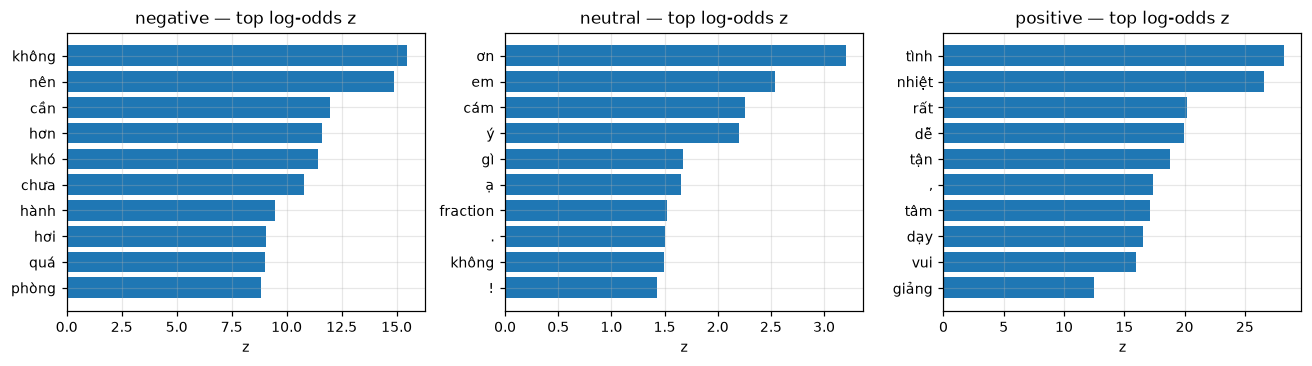

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, (name, t) in zip(axes, tops.items()):
    t = t.head(10).iloc[::-1]
    ax.barh(t['term'], t['z'])
    ax.set_title(f'{name} — top log-odds z')
    ax.set_xlabel('z')
plt.tight_layout(); plt.show()


### The single most important observation in this notebook

Look at the **scale** of the z-scores, not the words:

| class | top z |
|---|---|
| positive | **28.3** (`tình`, `nhiệt`, `rất`) |
| negative | **15.5** (`không`, `nên`, `cần`) |
| **neutral** | **3.2** (`ơn`, `em`, `cám`) |

**Neutral has no distinctive vocabulary — it is an order of magnitude weaker than either pole**,
and its top terms are politeness particles rather than sentiment words.

Neutral is defined by the **absence of both polarities**, not by any lexical signal of its own. A
bag-of-words model cannot represent an absence, which explains why the TF-IDF baseline reaches
only 0.497 neutral F1 while scoring 0.92+ on both poles. It also argues directly for an **ordinal**
head: neutral should be predicted as *not-negative AND not-positive*, not as a third thing with
its own evidence (docs/PROPOSALS.md T1).


In [19]:
print('--- topic (a contrast: these classes DO have their own vocabulary) ---')
pd.concat(
    {k: v.set_index('term')['z'].round(1) for k, v in V.top_terms(train, 'topic', top_k=10).items()},
    axis=1,
).head(10)


--- topic (a contrast: these classes DO have their own vocabulary) ---


,facility,lecturer,others,training_program
term,,,,
phòng,17.5,NaN,NaN,NaN
máy,14.8,NaN,NaN,NaN
bị,11.3,NaN,NaN,NaN
chiếu,8.9,NaN,NaN,NaN
trang,8.7,NaN,NaN,NaN
thiết,8.5,NaN,NaN,NaN
chất,7.0,NaN,NaN,NaN
nâng,6.5,NaN,NaN,NaN
quạt,6.2,NaN,NaN,NaN


`facility` has highly distinctive vocabulary, which is why **TF-IDF beats PhoBERT on that class**
(0.921 vs 0.905, 9× the seed std) — a contextual model has nothing to add where a keyword suffices.


### Length and vocabulary overlap by class


In [20]:
display(V.class_conditional_length(train, 'sentiment'))
print('vocabulary overlap (Jaccard):')
display(V.vocabulary_overlap(train, 'sentiment'))


,class,n,syllables_mean,syllables_p50,syllables_p95,chars_mean,share_under_5_syllables
0,negative,5325,16.88,13,40,70.4,0.0257
1,neutral,458,9.84,7,25,39.2,0.1921
2,positive,5643,12.25,10,25,50.0,0.0338


vocabulary overlap (Jaccard):


,negative,neutral,positive
negative,1.000,0.295,0.420
neutral,0.295,1.000,0.383
positive,0.420,0.383,1.000


**Neutral sentences are much shorter**: 9.8 syllables on average against 16.9 (negative) and 12.3
(positive), and **19.2% of them are under 5 syllables** versus 2.6% and 3.4%.

Two consequences. Length is a genuine *feature* the model can exploit — and a **confound** the
error analysis must control for, because attributing an error to meaning when it is really about
brevity would be wrong. A one-word sentence has almost no evidence in it either way.


---

## 8. Linguistic markers

Which phenomena are actually frequent enough to matter, and how predictive they are.


In [21]:
groups = {
    'negation': ['không', 'ko', 'chưa', 'chẳng', 'chả', 'đừng', 'khỏi'],
    'contrastive': ['nhưng', 'tuy', 'nhiên', 'mặc', 'dù', 'song'],
    'suggestion': ['nên', 'cần', 'mong', 'đề', 'nghị'],
    'intensifier': ['rất', 'quá', 'lắm', 'hơi', 'khá', 'cực'],
}
toks = full['sentence'].str.split()
rows = []
for g, words in groups.items():
    mask = toks.map(lambda t, w=set(words): bool(set(t) & w))
    ct = pd.crosstab(mask, full['sentiment'], normalize='index') * 100
    rows.append({
        'marker': g, 'sentences': int(mask.sum()), 'share': f'{mask.mean():.2%}',
        'negative %': round(ct.loc[True, 0], 1),
        'neutral %': round(ct.loc[True, 1], 1),
        'positive %': round(ct.loc[True, 2], 1),
    })
base = full['sentiment'].value_counts(normalize=True) * 100
rows.append({'marker': '(corpus baseline)', 'sentences': len(full), 'share': '100%',
             'negative %': round(base[0], 1), 'neutral %': round(base[1], 1),
             'positive %': round(base[2], 1)})
pd.DataFrame(rows)


,marker,sentences,share,negative %,neutral %,positive %
0,negation,3300,20.40%,84.4,4.5,11.1
1,contrastive,735,4.54%,75.5,5.0,19.5
2,suggestion,3176,19.64%,86.4,1.8,11.8
3,intensifier,4420,27.33%,44.2,1.1,54.7
4,(corpus baseline),16175,100%,46.0,4.3,49.7


* **Negation is abundant (20.4%) and highly predictive** — 84.3% negative against a 46% base rate.
  A unigram already captures that, so the interesting cases are negation *scope*
  (`không có gì để chê` = "nothing to criticize" → **positive**), not negation presence.
* **Suggestions are labelled `negative` 91.1% of the time**, not neutral. The annotation guideline
  reads a request for change as implicit criticism. My planned error taxonomy assumed the opposite
  and was corrected (ADR-007).


---

## 9. What the neutral class actually contains

Section 7 showed it has no vocabulary of its own. Reading it explains why.


In [22]:
pd.DataFrame({'neutral examples': train[train.sentiment == 1]['sentence'].sample(20, random_state=42).values})


,neutral examples
0,em không có ý kiến về mục này .
1,có nghĩ 2 buổi không hề báo trước .
2,sinh viên thực hiện làm bài tập theo nhóm .
3,everything .
4,cảm ơn thầy .
5,tất cả các hoạt động .
6,sự nhiệt tình giảng dạy của giảng viên .
7,sau khi thi kỳ thi cuối kỳ vừa rồi .
8,em chưa gặp thầy lần nào .
9,"thưa , không có ạ ."


It is **not** "balanced opinion". It is a grab-bag of at least six unrelated phenomena:

| sub-type | example |
|---|---|
| topic fragment, no opinion | `phương thức giảng dạy .` |
| politeness formula | `cảm ơn thầy .` |
| explicit non-opinion | `không có ý kiến khác .` |
| lukewarm / hedged | `cô dạy được .` · `thầy dạy lý thuyết tạm ổn .` |
| off-topic | `cho em xin ít con chip nfc .` |
| double negation | `không có gì để không hài lòng .` |

A single label spanning six phenomena across 458 training examples is a better explanation of the
class's difficulty than imbalance alone — and it predicts that **data-centric work (Tier D) will
help more than reweighting (Tier A)**, which is a testable claim.


---

## 10. Tokenizer fit

Subwords per syllable. A fertility near 1.0 means PhoBERT's vocabulary covers this corpus well;
high fertility means words are being shattered, which is what happens to out-of-vocabulary text.


In [23]:
fert = V.subword_fertility(train.sample(3000, random_state=0))
print(json.dumps({k: v for k, v in fert.items() if k != 'worst_examples'}, indent=2))
print('worst-fitting sentences:')
display(pd.DataFrame(fert['worst_examples']).head(6))


{
  "model": "vinai/phobert-base",
  "fertility_mean": 1.02,
  "fertility_p50": 1.0,
  "fertility_p95": 1.111,
  "share_above_2": 0.0003
}
worst-fitting sentences:


,text,syllables,subwords,fertility
0,đề khó colonbigsmile .,4,9,2.25
1,cô wzjwz45 dạy hay !,5,10,2.00
2,dễ thương coloncontemn .,4,8,2.00
3,giáo viên dạy lớp wzjwz315 không phải là cô wz...,11,21,1.91
4,cô wzjwz106 hay cho nghỉ .,6,11,1.83
5,phòng wzjwz98 dãy nhà wzjwz99 buổi chiều quá n...,12,22,1.83


---

## 11. What this EDA decided

| Finding | Decision | Where |
|---|---|---|
| Neutral is 4.01% of train; blind-to-neutral scores 0.947 acc / 0.922 wtd / 0.649 macro | macro-F1 is the headline metric | ADR-001 |
| Splits verified 11,426 / 1,583 / 3,166; pinned by SHA256 | official split used unchanged | ADR-002 |
| Subword p99.9 = 87 | **`max_length` = 96** → 3.49× CPU p95 with dynamic padding | Gate G0 |
| 0 uppercase sentences | drop the lowercasing ablation | ADR-006 |
| 1 underscore in 16,175 | the corpus is unsegmented → the segmentation ablation is real | ADR-006 |
| Teencode 0.16%, no-diacritics 0.14% | robustness targets, measured by perturbation | ADR-007 |
| Suggestions are 91.1% `negative` | error taxonomy corrected | ADR-007 |
| Cramér's V = 0.344; neutral is 11× more likely in `others` | multi-task justified before running | PROPOSALS T3 |
| Leakage 0 exact / 1.74% normalized | immaterial, disclosed, pinned by a test | DATA_CARD L9 |
| ~4.8% label disagreement on identical text | measured ceiling bound | DATA_CARD L4 |
| **Neutral top z = 3.2 vs 28.3 / 15.5** | neutral has no vocabulary → **ordinal head** | PROPOSALS T1 |
| Neutral is 9.8 syllables vs 16.9 / 12.3 | length is a feature *and* an error-analysis confound | PROPOSALS |
| `facility` has distinctive vocabulary | explains TF-IDF beating PhoBERT there → hybrid | PROPOSALS T4 |

The last three rows came out of the lexical analysis in § 7, which was the part of the EDA that
was missing when the modelling started. It changed the technique roadmap.
